In [12]:
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader
import torch.nn as nn

In [29]:
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(45),
    transforms.RandomAutocontrast(),
    transforms.ToTensor(),
    transforms.Resize((64, 64)),
])

dataset_train = ImageFolder(
    "xray_dataset_covid19/train",
    transform=train_transforms,
)

In [30]:
dataloader_train = DataLoader(
    dataset_train,
    shuffle=True,
    batch_size=1
)

torch.Size([1, 3, 64, 64])
torch.Size([64, 64, 3])


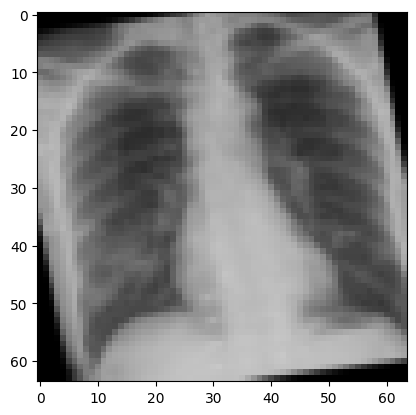

In [31]:
image, label = next(iter(dataloader_train))
print(image.shape)

image = image.squeeze().permute(1, 2, 0)
print(image.shape)

import matplotlib.pyplot as plt
plt.imshow(image)
plt.show()

In [32]:
class Net(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Flatten(),
        )

        self.classifier = nn.Linear(64*16*16, num_classes)

    def forward(self, x):
        x = self.feature_extractor(x)
        print(x.shape)
        x = self.classifier(x)
        return x

In [15]:
import torch.optim as optim

In [36]:
net = Net(num_classes=2)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)

In [37]:
for epoch in range(10):
    for images, labels in dataloader_train:
        optimizer.zero_grad()
        outputs = net(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size(

In [48]:
test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((64, 64))
])

database_test = ImageFolder(
    "xray_dataset_covid19/test",
    transform=test_transforms
)

In [49]:
import torch
from torchmetrics import Precision, Recall

metric_precision = Precision(task="multiclass", num_classes=2, average=None)
metric_recall = Recall(task="multiclass", num_classes=2, average=None)

# Create test dataloader
dataloader_test = DataLoader(
    database_test,
    shuffle=False,
    batch_size=1
)

# Set model to evaluation mode
net.eval()

with torch.no_grad():
    for images, labels in dataloader_test:
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        metric_precision(predicted, labels)
        metric_recall(predicted, labels)

precision = metric_precision.compute()
recall = metric_recall.compute()

torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])
torch.Size([1, 16384])


In [52]:

per_class_precision = {
    k: precision[v].item() for k, v in database_test.class_to_idx.items()
}
per_class_recall = {
    k: recall[v].item() for k, v in database_test.class_to_idx.items()
}

print("Per-class precision:", per_class_precision)
print("Per-class recall:", per_class_recall)

Per-class precision: {'NORMAL': 1.0, 'PNEUMONIA': 0.8333333134651184}
Per-class recall: {'NORMAL': 0.800000011920929, 'PNEUMONIA': 1.0}


# Initial Commit Message
This commit sets up the project structure for the COVID-19 X-ray dataset analysis, including directories for training and testing data.